# PCA with NumPy
Two approaches side-by-side — **Covariance + Eigen** and **SVD** — on California Housing.
Model saved to `../Models/pca_numpy.npz`.

## 1. Load & Standardise

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.datasets import fetch_california_housing

raw      = fetch_california_housing(as_frame=True)
features = list(raw.feature_names)
X_raw    = raw.frame[features].values.astype(np.float64)   # (n, p)
y        = raw.frame['MedHouseVal'].values
n, p     = X_raw.shape

# Standardise
X_mean = X_raw.mean(axis=0)          # (p,)
X_std  = X_raw.std(axis=0, ddof=1)   # (p,)  sample std
X      = (X_raw - X_mean) / X_std    # (n, p)

print(f"Shape: {n:,} × {p}  |  Post-scale std ≈ {X.std(axis=0).round(4)}")

Shape: 20,640 × 8  |  Post-scale std ≈ [1. 1. 1. 1. 1. 1. 1. 1.]


---
# Approach A — Covariance Matrix + Eigendecomposition

Classic formulation:
$$C = \frac{1}{n-1} X^T X, \quad C = V \Lambda V^T$$

- Explicit $p \times p$ covariance matrix (cheap when $p$ is small)
- `np.linalg.eigh` exploits symmetry — faster and more stable than `np.linalg.eig`

In [2]:
C            = (X.T @ X) / (n - 1)                  # (p, p)
eigvals, V   = np.linalg.eigh(C)                     # ascending order
order        = np.argsort(eigvals)[::-1]
eigvals      = eigvals[order]
V            = V[:, order]                           # (p, p) — columns = components

evr_cov      = eigvals / eigvals.sum()
cumvar_cov   = evr_cov.cumsum()

pd.DataFrame({
    'Eigenvalue':        eigvals.round(4),
    'Explained Var (%)': (evr_cov * 100).round(2),
    'Cumulative (%)':    (cumvar_cov * 100).round(2)
}, index=[f'PC{i+1}' for i in range(p)])

,Eigenvalue,Explained Var (%),Cumulative (%)
PC1,2.0269,25.34,25.34
PC2,1.8813,23.52,48.85
PC3,1.2711,15.89,64.74
PC4,1.0310,12.89,77.63
PC5,1.0031,12.54,90.17
PC6,0.6594,8.24,98.41
PC7,0.0816,1.02,99.43
PC8,0.0456,0.57,100.00


---
# Approach B — Singular Value Decomposition (SVD)

The **numerically preferred** approach — avoids squaring the data matrix (which squares
the condition number and can amplify floating-point errors).

$$X = U \Sigma V^T$$

- $U$ — left singular vectors, shape $(n, p)$
- $\Sigma$ — diagonal singular values, shape $(p,)$
- $V^T$ — right singular vectors = **principal components**, shape $(p, p)$

The connection to eigendecomposition:
$$C = \frac{X^T X}{n-1} = \frac{V \Sigma^2 V^T}{n-1} \implies \lambda_i = \frac{\sigma_i^2}{n-1}$$

In [3]:
U, S, Vt  = np.linalg.svd(X, full_matrices=False)   # economy SVD
# Vt: (p, p) — each row is a principal component direction
components_svd = Vt                                   # (p, p)

eigvals_svd  = (S ** 2) / (n - 1)                    # (p,)
evr_svd      = eigvals_svd / eigvals_svd.sum()
cumvar_svd   = evr_svd.cumsum()

pd.DataFrame({
    'Singular Value':    S.round(4),
    'Eigenvalue':        eigvals_svd.round(4),
    'Explained Var (%)': (evr_svd * 100).round(2),
    'Cumulative (%)':    (cumvar_svd * 100).round(2)
}, index=[f'PC{i+1}' for i in range(p)])

,Singular Value,Eigenvalue,Explained Var (%),Cumulative (%)
PC1,204.5341,2.0269,25.34,25.34
PC2,197.0486,1.8813,23.52,48.85
PC3,161.9693,1.2711,15.89,64.74
PC4,145.8752,1.0310,12.89,77.63
PC5,143.8821,1.0031,12.54,90.17
PC6,116.6574,0.6594,8.24,98.41
PC7,41.0388,0.0816,1.02,99.43
PC8,30.6730,0.0456,0.57,100.00


## Verify: Both Approaches Give the Same Components

In [4]:
# Eigenvectors are identical up to sign flip — take absolute values for comparison
cov_comps = np.abs(V.T)           # (p, p)  rows = components from cov approach
svd_comps = np.abs(components_svd) # (p, p)  rows = components from SVD

max_diff = np.max(np.abs(cov_comps - svd_comps))
print(f"Max absolute difference between cov and SVD components: {max_diff:.2e}")
print("Both approaches are numerically equivalent ✓" if max_diff < 1e-10 else "Difference detected")

Max absolute difference between cov and SVD components: 8.22e-15
Both approaches are numerically equivalent ✓


## Scree Plot — Both Approaches Overlaid

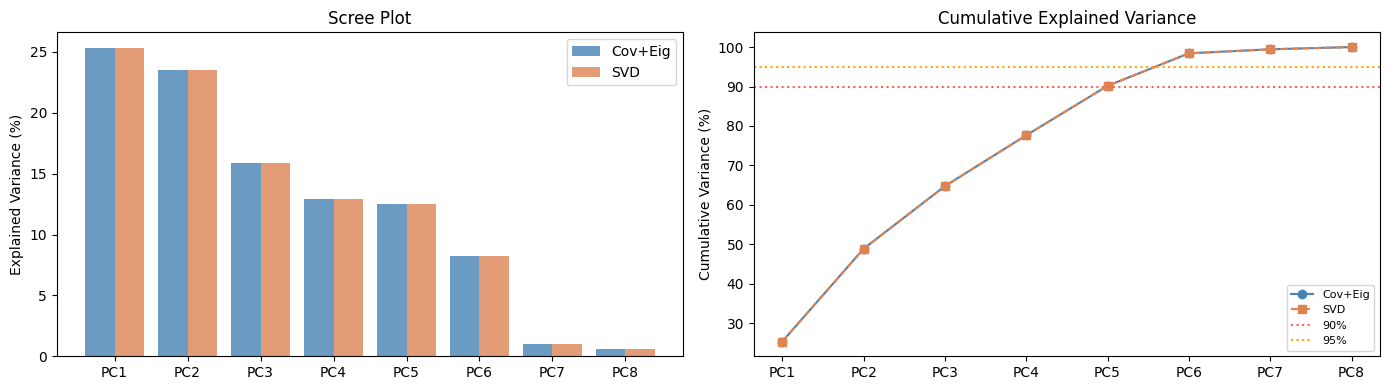

In [5]:
pcs = [f'PC{i+1}' for i in range(p)]
x   = np.arange(p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(x - 0.2, evr_cov * 100,  0.4, label='Cov+Eig', color='steelblue', alpha=0.8)
ax1.bar(x + 0.2, evr_svd * 100,  0.4, label='SVD',     color='#DD8452',   alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(pcs)
ax1.set_ylabel('Explained Variance (%)'); ax1.set_title('Scree Plot')
ax1.legend()

ax2.plot(pcs, cumvar_cov * 100, marker='o', label='Cov+Eig', color='steelblue')
ax2.plot(pcs, cumvar_svd * 100, marker='s', linestyle='--', label='SVD', color='#DD8452')
ax2.axhline(90, color='tomato', linestyle=':', label='90%')
ax2.axhline(95, color='orange', linestyle=':', label='95%')
ax2.set_ylabel('Cumulative Variance (%)'); ax2.set_title('Cumulative Explained Variance')
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

## Project to 2D & Visualise

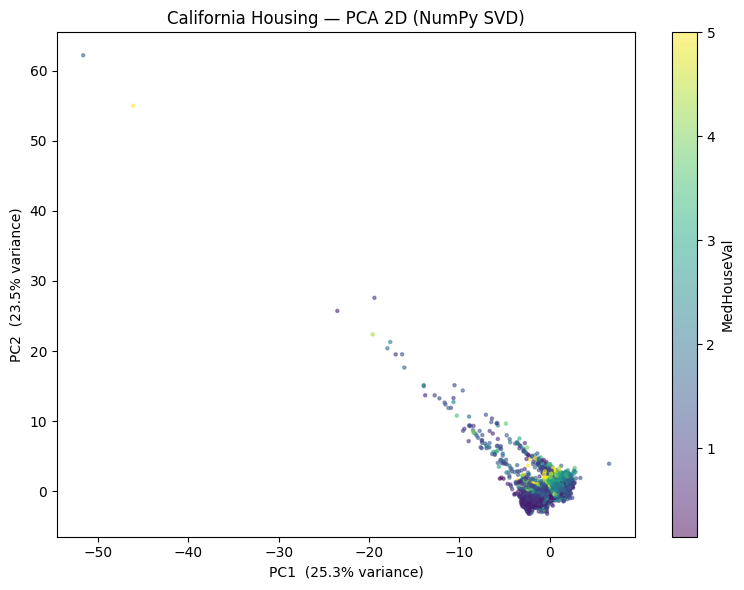

In [6]:
K = 2
# Using SVD components (preferred)
X_pca = X @ components_svd[:K].T    # (n, K)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(sc, ax=ax, label='MedHouseVal')
ax.set_xlabel(f'PC1  ({evr_svd[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({evr_svd[1]*100:.1f}% variance)')
ax.set_title('California Housing — PCA 2D (NumPy SVD)')
plt.tight_layout(); plt.show()

## Loadings Plot (Biplot)

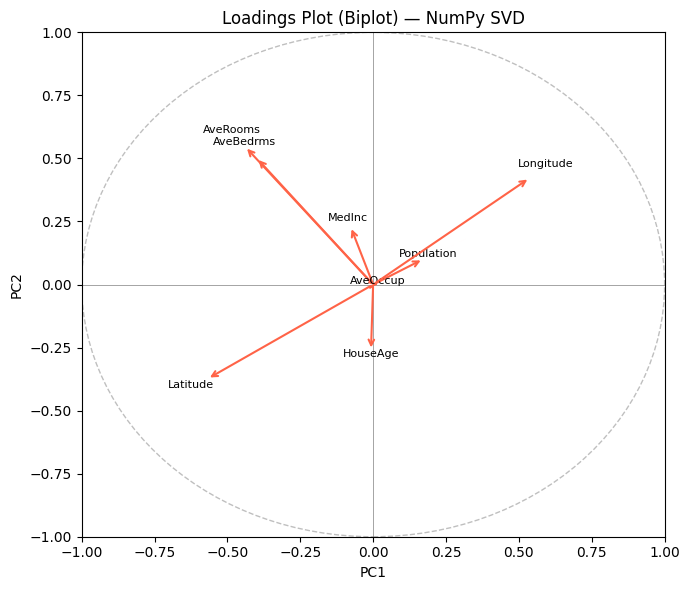

In [7]:
loadings = components_svd[:2].T    # (p, 2)

fig, ax = plt.subplots(figsize=(7, 6))
for i, feat in enumerate(features):
    ax.annotate('', xy=(loadings[i, 0], loadings[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))
    ax.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, feat, fontsize=8, ha='center')

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
circle = plt.Circle((0,0), 1, fill=False, linestyle='--', color='grey', alpha=0.5)
ax.add_patch(circle)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Loadings Plot (Biplot) — NumPy SVD')
plt.tight_layout(); plt.show()

## Reconstruction Error vs k

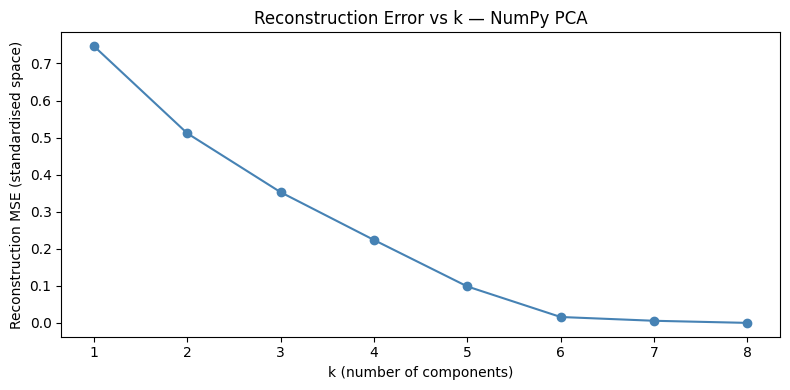

  k=1: MSE=0.746595  |  variance retained=25.34%
  k=2: MSE=0.511444  |  variance retained=48.85%
  k=3: MSE=0.352565  |  variance retained=64.74%
  k=4: MSE=0.223692  |  variance retained=77.63%
  k=5: MSE=0.098316  |  variance retained=90.17%
  k=6: MSE=0.015898  |  variance retained=98.41%
  k=7: MSE=0.005698  |  variance retained=99.43%
  k=8: MSE=0.000000  |  variance retained=100.00%


In [8]:
recon_errors = []
for k in range(1, p + 1):
    Vk      = components_svd[:k].T              # (p, k)
    X_proj  = X @ Vk                            # (n, k)
    X_recon = X_proj @ Vk.T                     # (n, p)
    recon_errors.append(np.mean((X - X_recon) ** 2))

plt.figure(figsize=(8, 4))
plt.plot(range(1, p + 1), recon_errors, marker='o', color='steelblue')
plt.xlabel('k (number of components)')
plt.ylabel('Reconstruction MSE (standardised space)')
plt.title('Reconstruction Error vs k — NumPy PCA')
plt.xticks(range(1, p + 1))
plt.tight_layout(); plt.show()

for k, err in enumerate(recon_errors, 1):
    print(f"  k={k}: MSE={err:.6f}  |  variance retained={cumvar_svd[k-1]*100:.2f}%")

## Save Model to `../Models/`

In [9]:
save_path = '../Models/pca_numpy.npz'
np.savez_compressed(
    save_path,
    feature_names       = np.array(features),
    components          = components_svd,         # (p, p)  rows = principal components
    singular_values     = S,                      # (p,)
    eigenvalues         = eigvals_svd,            # (p,)
    explained_var_ratio = evr_svd,                # (p,)
    x_mean              = X_mean,                 # (p,)
    x_std               = X_std                   # (p,)
)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/pca_numpy.npz  (2.3 KB)
